# Transient Temperature Simulation in a Closed District Heating Grid

This example demonstrates a transient temperature simulation of a simple closed district heating network with pandapipes.

The network consists of:

- one circulation pump,
- one heat consumer,
- two pipes,
- and four junctions forming a closed loop.

The goal of this example is to show how the temperature propagates through the network over time and how the system slowly approaches a stationary thermal state.

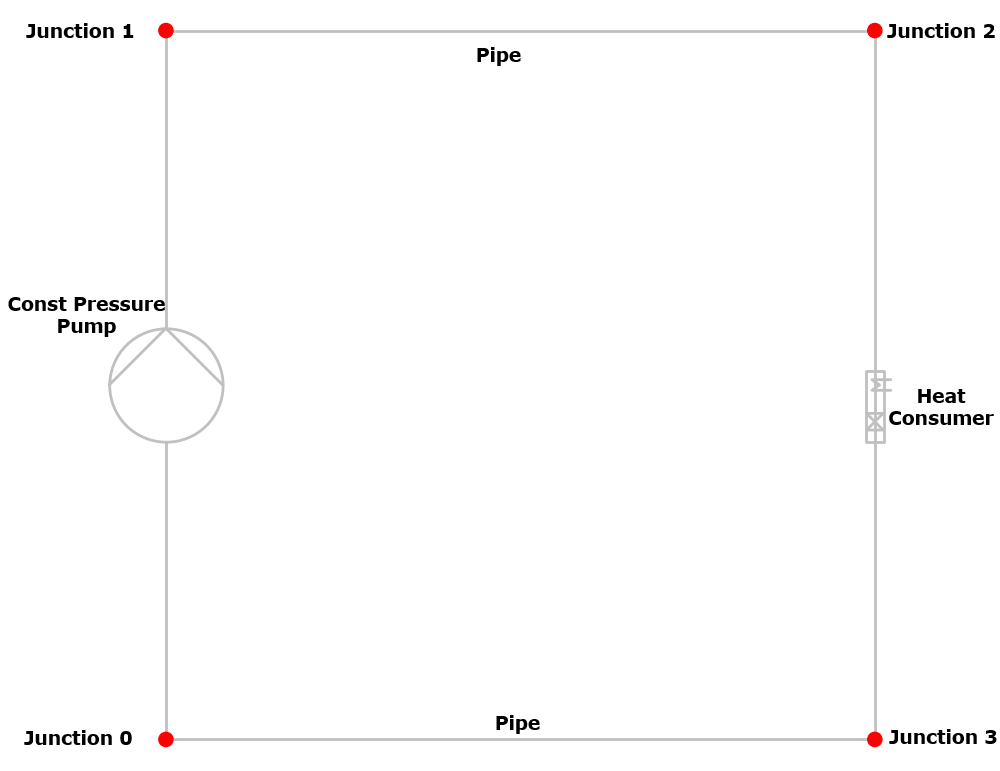

# Network Setup

The following figure shows the topology of the network used in this example.

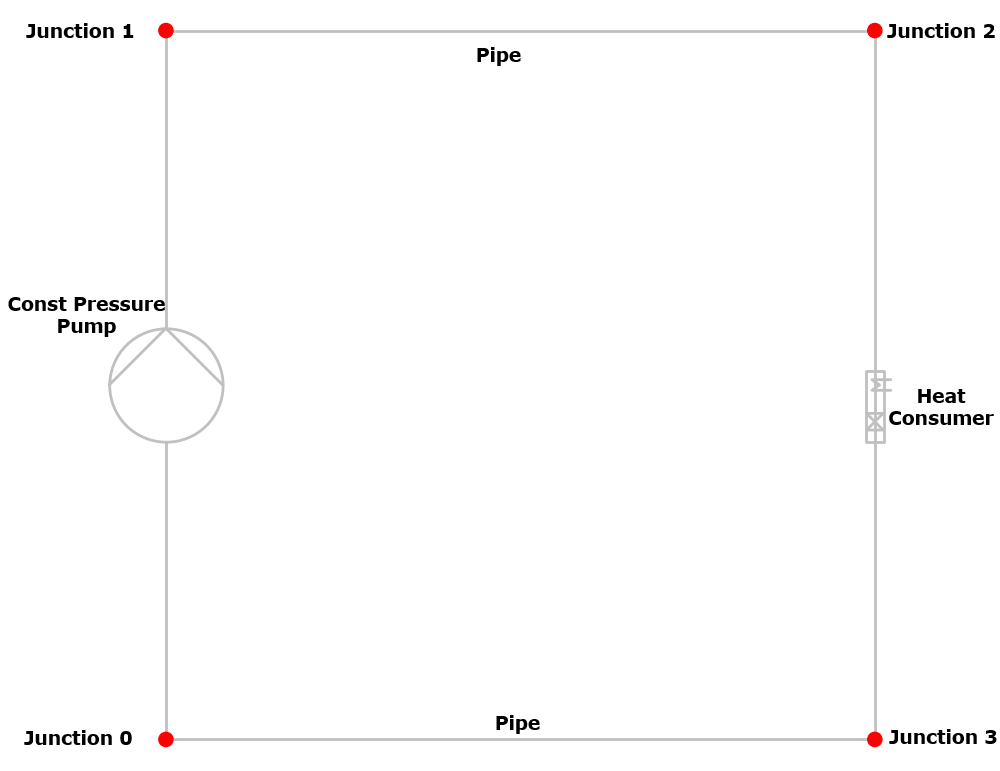

First, pandapipes and the required libraries are imported.
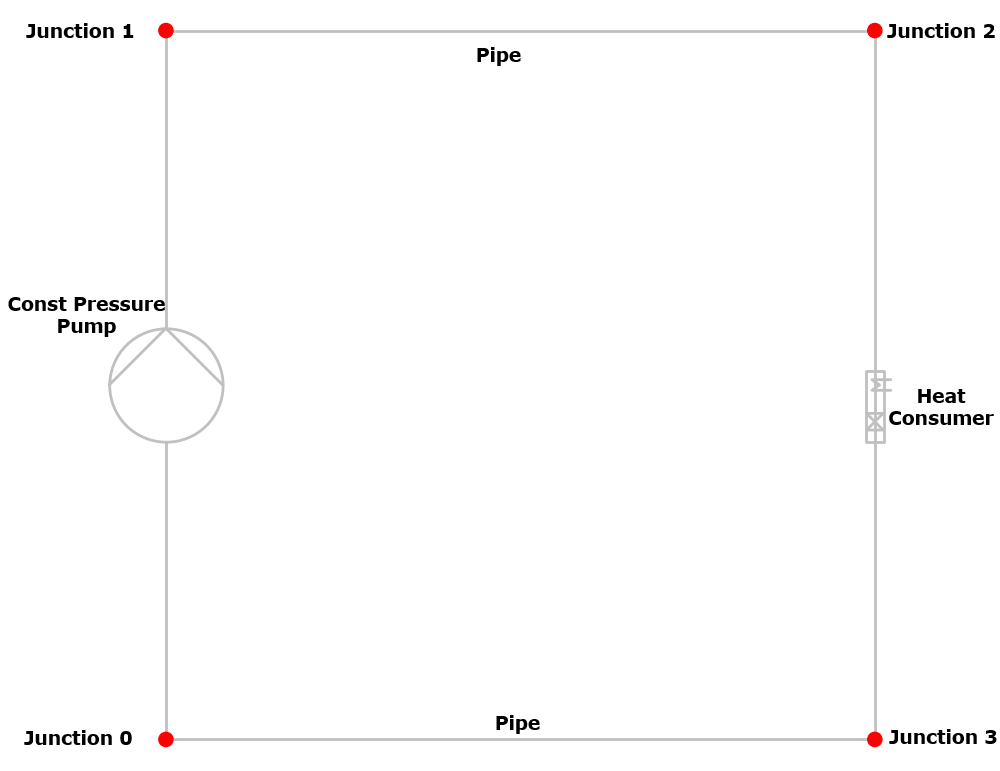

In [10]:
import pandapipes as pp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
from matplotlib.collections import LineCollection
from pandapipes.component_models import Pipe
from pandapipes.timeseries.run_time_series import run_timeseries, _call_output_writer
from pandapower.timeseries.output_writer import OutputWriter
import tempfile

import tempfile
An empty network with water as working fluid is created.

In [11]:
net = pp.create_empty_network(fluid="water")

# Junctions

Four junctions are created.
Initially, the complete network starts with a temperature of 20 °C.

In [12]:
j0 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 0", geodata=(0, 0))
j1 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 1", geodata=(0, 10))
j2 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 2", geodata=(10, 10))
j3 = pp.create_junction(net, pn_bar=4, tfluid_k=293.15, name="junction 3", geodata=(10, 0))

# Circulation Pump

The circulation pump continuously feeds hot water with a supply temperature of 70 °C into the network.

In [13]:
pp.create_circ_pump_const_pressure( net, return_junction=j0, flow_junction=j1, p_flow_bar=4, plift_bar=1.5,
    t_flow_k=273.15 + 70, type="auto", name="const_pressure_pump")

np.int64(0)

# Heat Consumer

A heat consumer extracts thermal energy from the network.

In [14]:
pp.create_heat_consumer(net, from_junction=j2, to_junction=j3, qext_w=None, controlled_mdot_kg_per_s=2,
    deltat_k=20, treturn_k=None, type="heat_consumer")

np.int64(0)

 23%|██▎       | 139/601 [00:20<00:34, 13.45it/s]

The heat consumer is controlled by a fixed temperature difference of 20 K. Therefore, the water temperature decreases by approximately 20 °C while passing through the consumer. This creates the temperature difference between the supply and return line that is characteristic of district heating systems.

# Pipes

Two pipes are used to form the closed loop. The pipes are created with a predefined standard type. The ambient temperature is set with text_k and is used for the heat loss calculation.

In [15]:
pp.create_pipe(net, from_junction=j1, to_junction=j2, std_type="ISOPLUS_DRE100_STD", length_km=1, k_mm=0.1, loss_coefficient=0, sections=10, text_k=273.15 + 10, qext_w=0., name="pipe_0_1", type="pipe")

pp.create_pipe(net, from_junction=j3, to_junction=j0, std_type="ISOPLUS_DRE100_STD", length_km=1, k_mm=0.1, loss_coefficient=0, sections=10, text_k=273.15 + 10, qext_w=0., name="pipe_1_2", type="pipe")

np.int64(1)

The parameter sections=10 is important for the transient simulation.
Each pipe is internally discretized into multiple sections, which allows pandapipes to resolve the temperature distribution along the pipe length.

## Visualization Function

In [16]:
def plot_temperature_snapshot(net, time_s):

    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(293.15, 343.15)

    coords = {
        0: (0, 0),
        1: (0, 1),
        2: (1, 1),
        3: (1, 0)
    }

    fig, ax = plt.subplots(figsize=(6, 5))

    for p, row in net.pipe.iterrows():

        fj = row.from_junction
        tj = row.to_junction

        pipe_results = Pipe.get_internal_results(net, [p])
        t_int = pipe_results["TINIT"]

        if t_int.ndim == 2:
            t_int = t_int[:, 1]

        temps = np.r_[
            net.res_junction.at[fj, "t_k"],
            t_int,
            net.res_junction.at[tj, "t_k"]
        ]

        xs = np.linspace(coords[fj][0], coords[tj][0], len(temps))
        ys = np.linspace(coords[fj][1], coords[tj][1], len(temps))

        pts = np.c_[xs, ys].reshape(-1, 1, 2)
        segs = np.c_[pts[:-1], pts[1:]].reshape(-1, 2, 2)

        lc = LineCollection(segs, cmap=cmap, norm=norm, linewidth=4)
        lc.set_array((temps[:-1] + temps[1:]) / 2)

        ax.add_collection(lc)

        ax.scatter(xs, ys, c=temps, cmap=cmap, norm=norm, s=45, zorder=3)

    ax.plot([0, 0], [0, 1], color="gray", linestyle="--", linewidth=2)
    ax.text(-0.12, 0.5, "Pump", rotation=90, va="center", fontsize=10)

    ax.plot([1, 1], [1, 0], color="gray", linestyle="--", linewidth=2)
    ax.text(0.88, 0.5, "Consumer", rotation=90, va="center", fontsize=10)

    fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap, norm=norm),
        ax=ax,
        label="Temperature [K]"
    )

    ax.set_title(f"Temperature distribution at t = {time_s} s")
    ax.set_aspect("equal")
    ax.axis("off")

    plt.show()

## Transient SimulationTime and Series Settings

The transient simulation is performed with a time step of 60 seconds and a total simulation time of 36000 seconds.

An OutputWriter is used to store the simulation results at each time step. In this example, the junction temperatures, junction pressures, and the pipe inlet and outlet temperatures are recorded.

The custom output writer is additionally used to create temperature plots at selected times during the simulation.

The simulation is started with `run_timeseries`. The option `transient=True` activates the time-dependent temperature calculation, while `dt=60` defines the time step size. The simulation is performed in `sequential` mode, which means that pandapipes solves the hydraulic and thermal equations consecutively at every time step.

The plots show that after approximately one circulation time, around 9000 seconds, the supply pipe is already close to the pump temperature. However, the return pipe has not yet reached its final temperature. The return temperature increases mainly during the following circulation and becomes almost stationary after the second loop.

In [17]:
dt = 60
t_end = 36000

time_steps = range(0, t_end + dt, dt)
plot_times_s = {600, 1200, 2400, 3600, 7200, 9000, 18000, 27000, 36000,}

ow = OutputWriter(
    net,
    time_steps=time_steps,
    output_path=tempfile.gettempdir(),
    log_variables=[]
)

ow.log_variable("res_junction", "t_k")
ow.log_variable("res_junction", "p_bar")
ow.log_variable("res_pipe", "t_from_k")
ow.log_variable("res_pipe", "t_to_k")

def my_output_writer(net, time_step, pf_converged, ctrl_converged, ts_variables):
    _call_output_writer(net, time_step, pf_converged, ctrl_converged, ts_variables)
    physical_time_s = time_step
    # if time_step in plot_times_s:
    #     plot_temperature_snapshot(net, time_step)
    #
    # print(physical_time_s)
    # print(net.res_junction["t_k"])

run_timeseries(
    net,
    time_steps=time_steps,
    output_writer_fct=my_output_writer,
    mode="sequential",
    transient=True,
    dt=dt,
)


100%|██████████| 601/601 [00:22<00:00, 26.70it/s]


# Temperature Distribution During the Simulation

The following figure shows the temperature distribution inside the network at different timesteps.
The internal pipe sections are visualized explicitly.
The plots show that after approximately one circulation time, around 9000 seconds, the supply pipe is already close to the pump temperature. However, the return pipe has not yet reached its final temperature. The return temperature increases mainly during the following circulation and becomes almost stationary after the second loop.
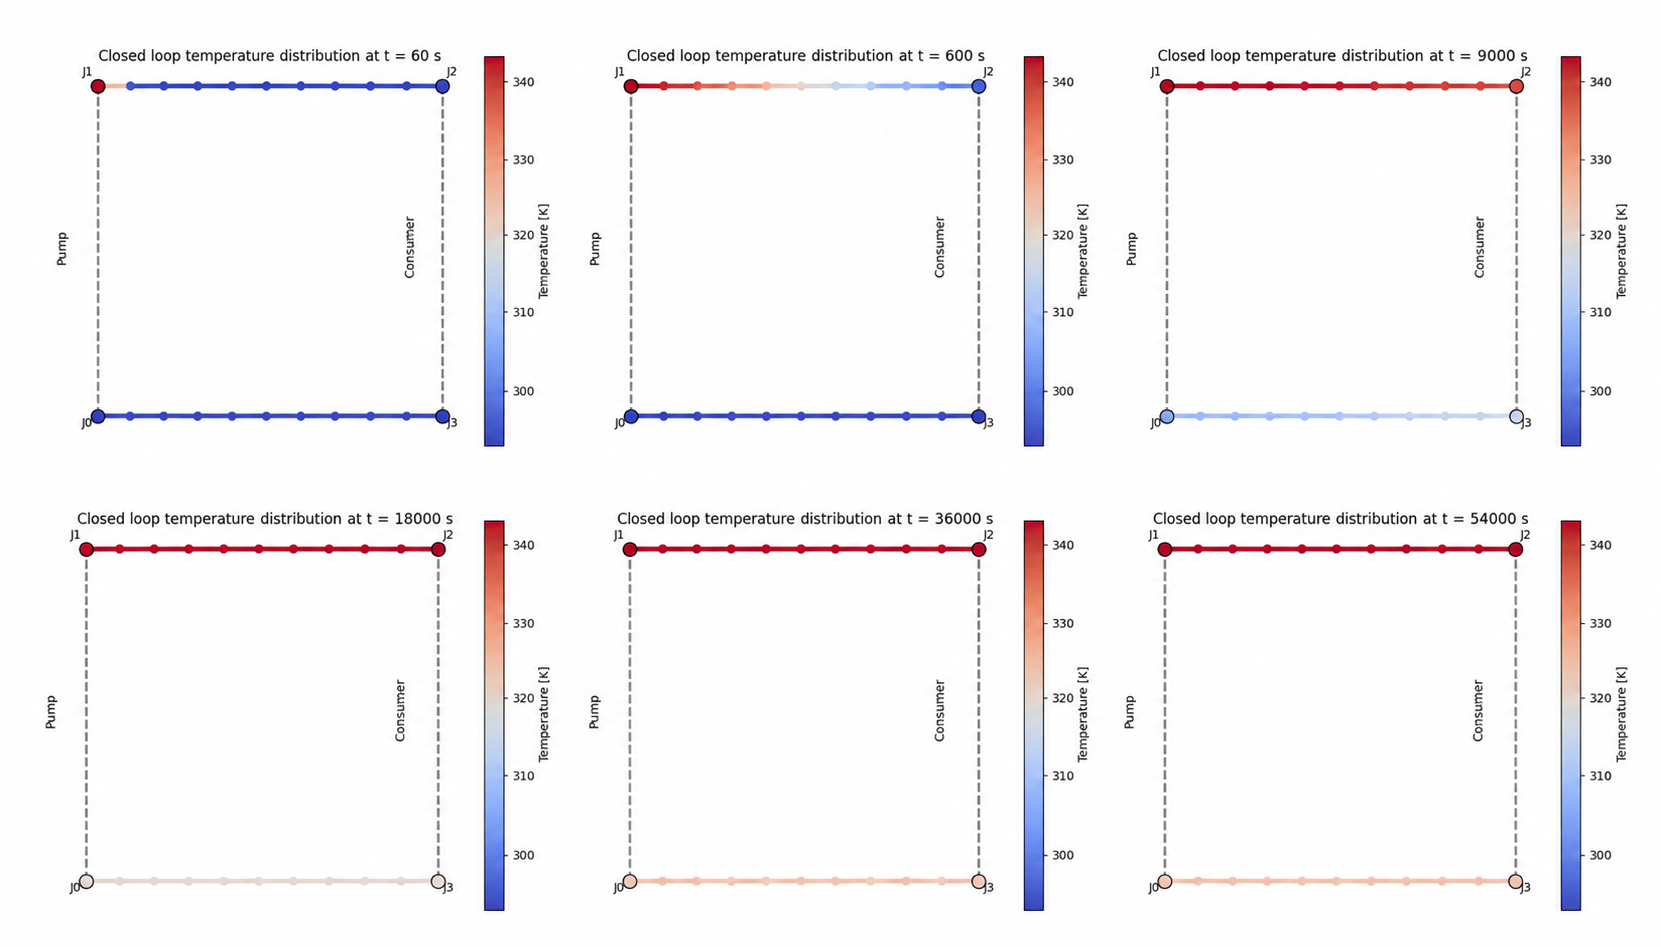
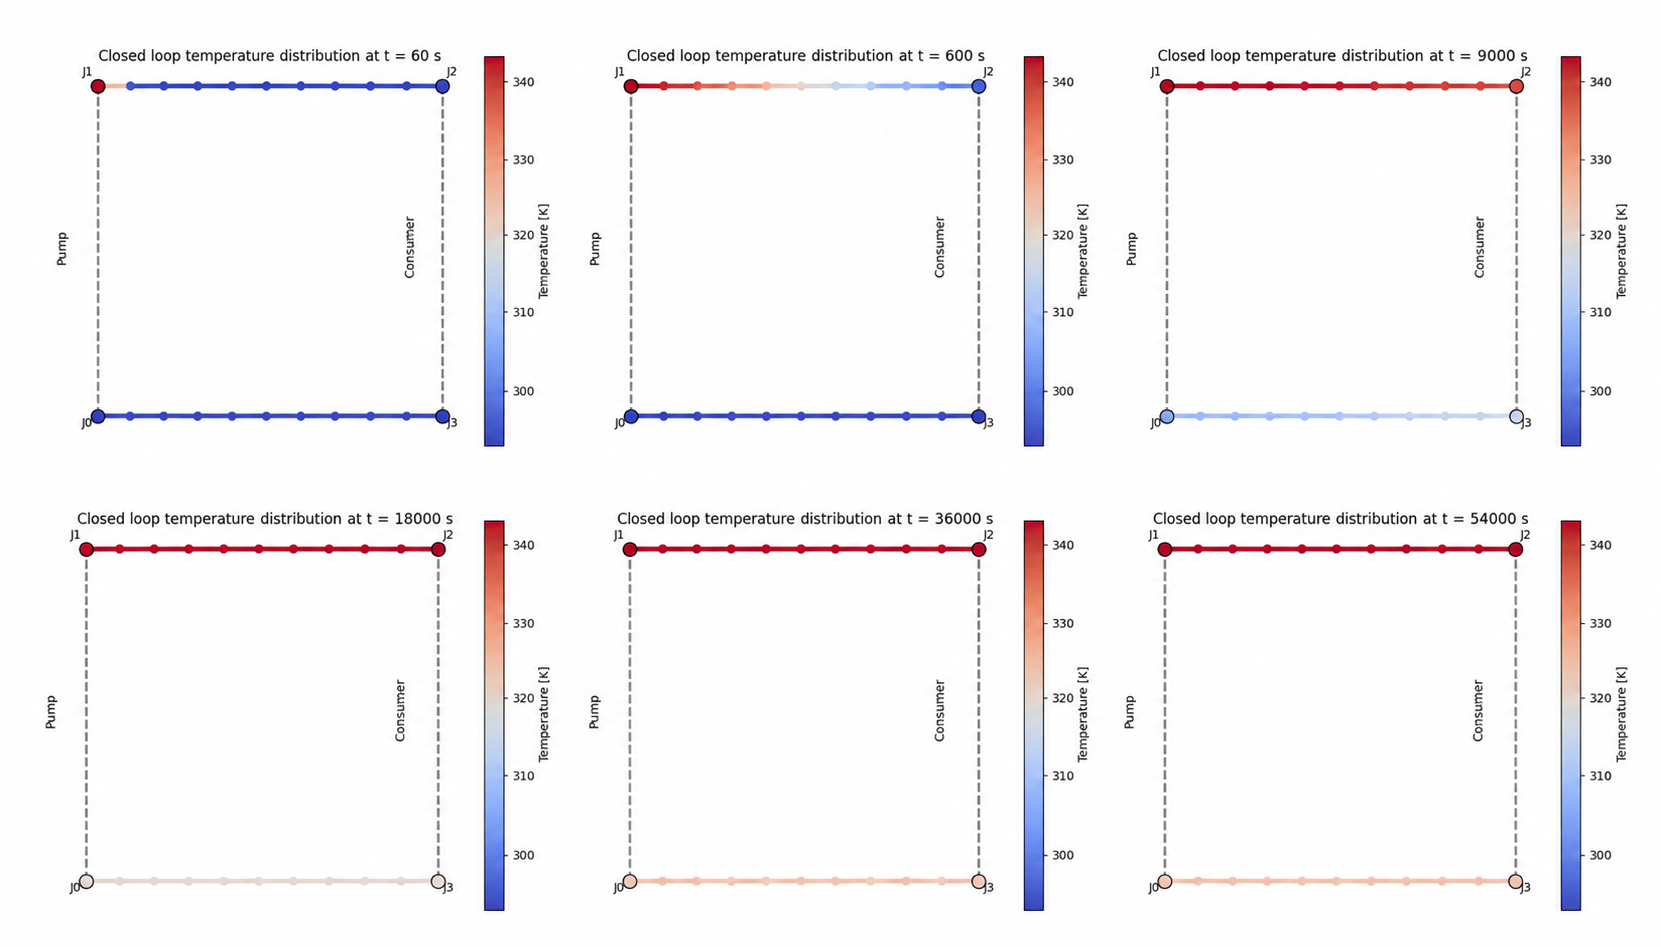

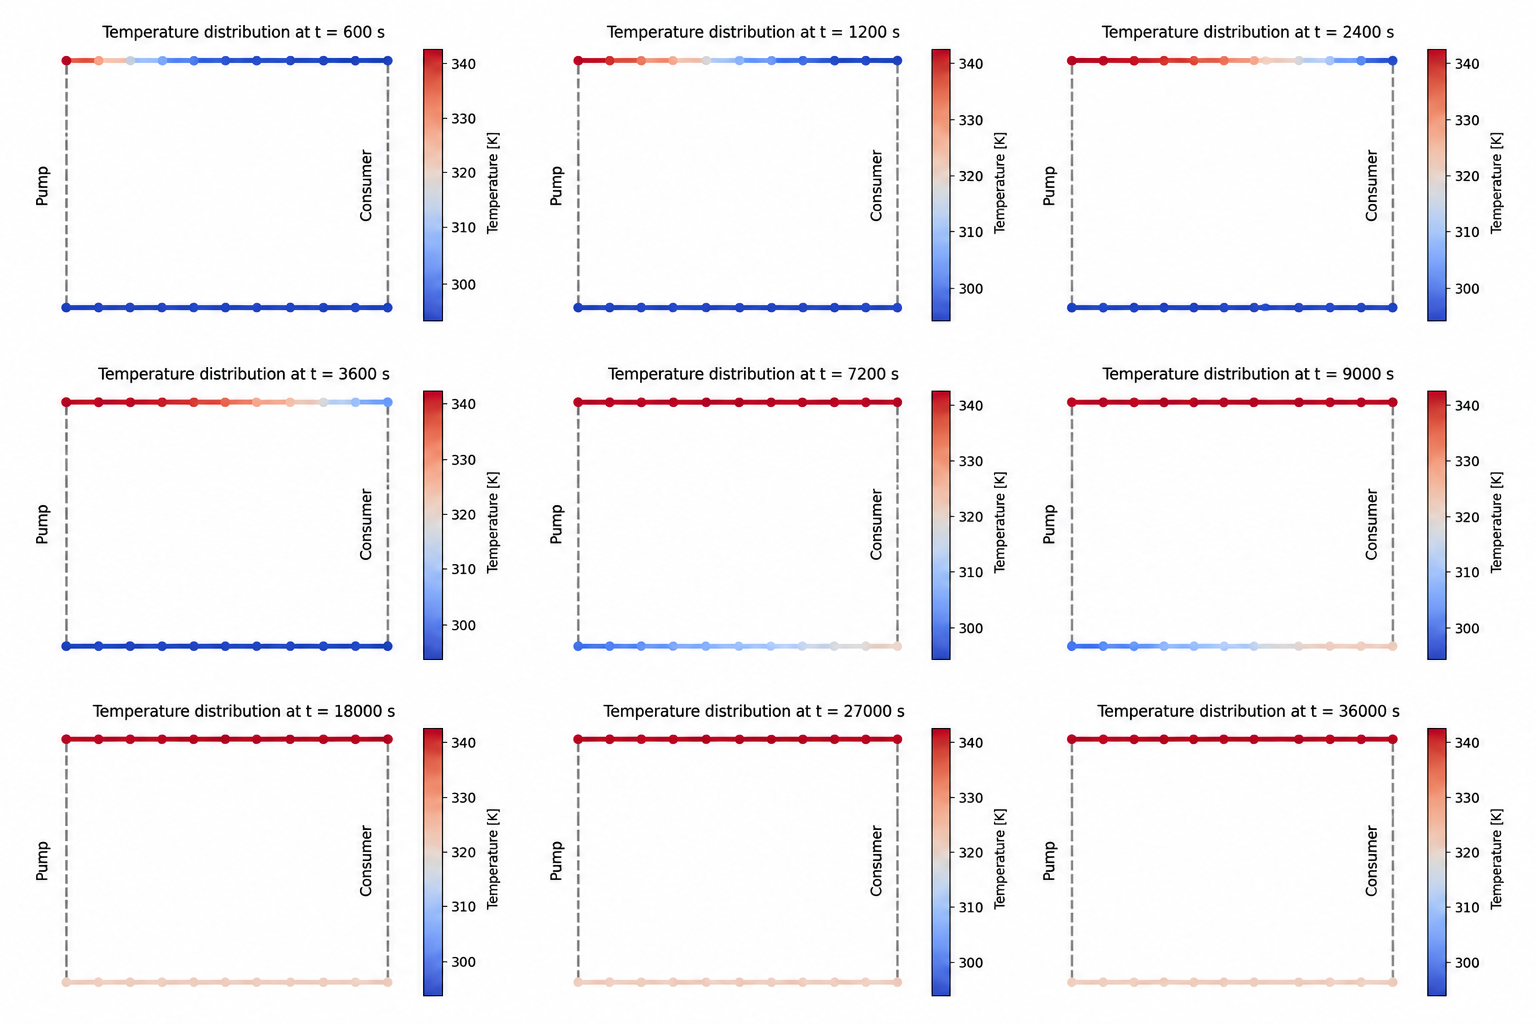
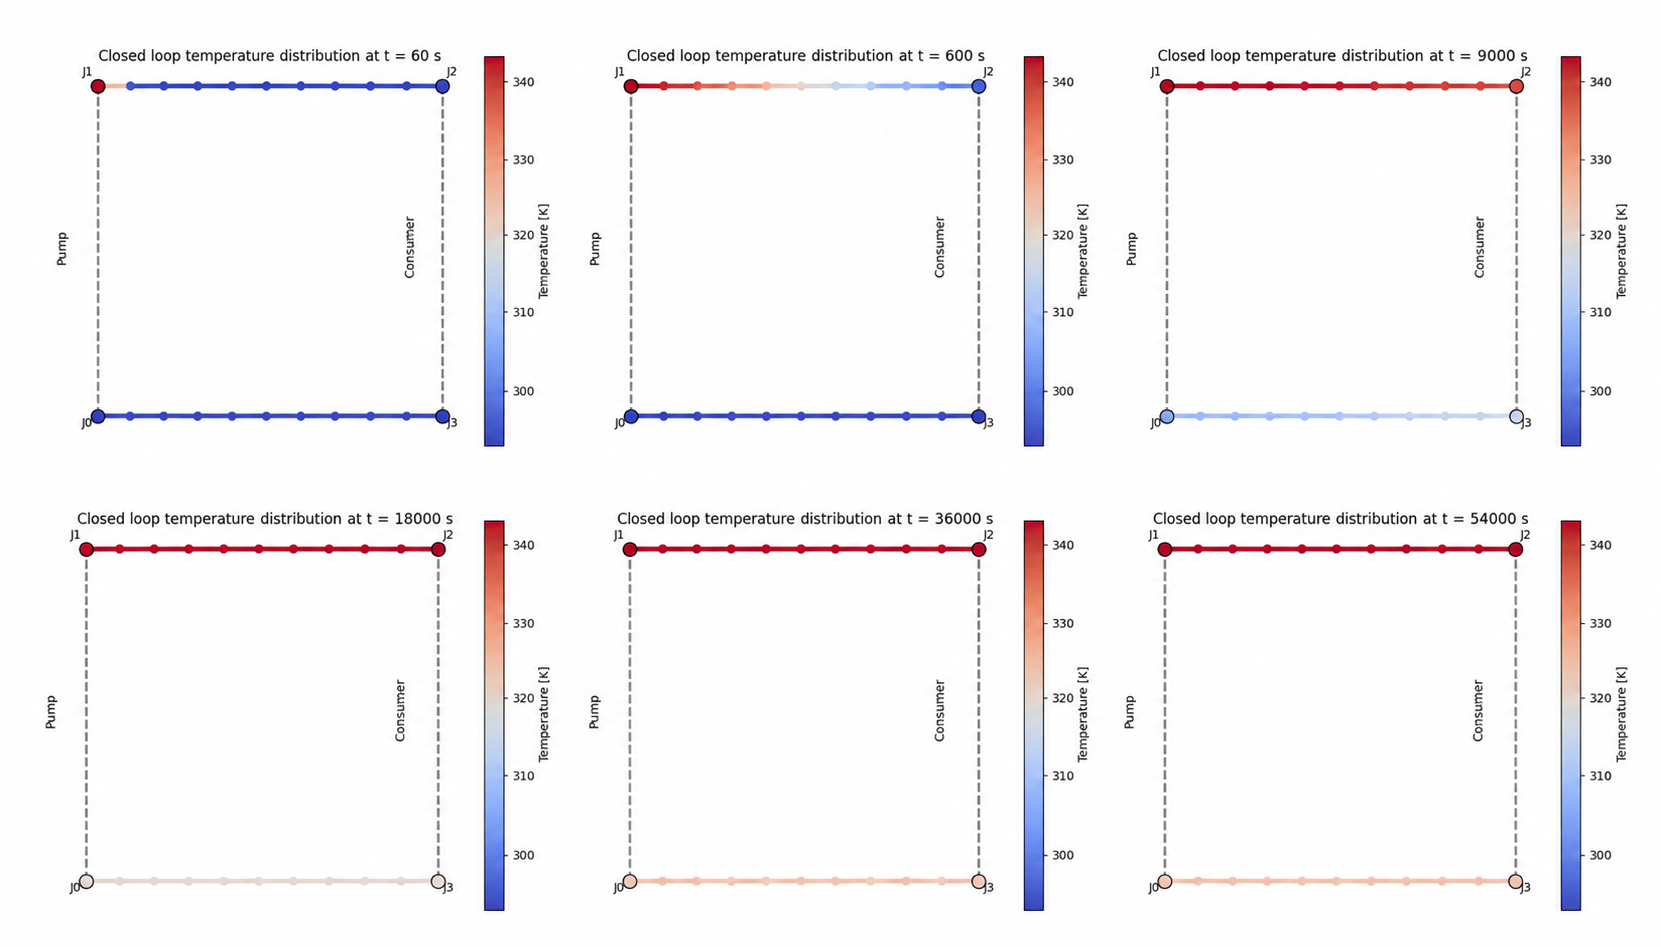
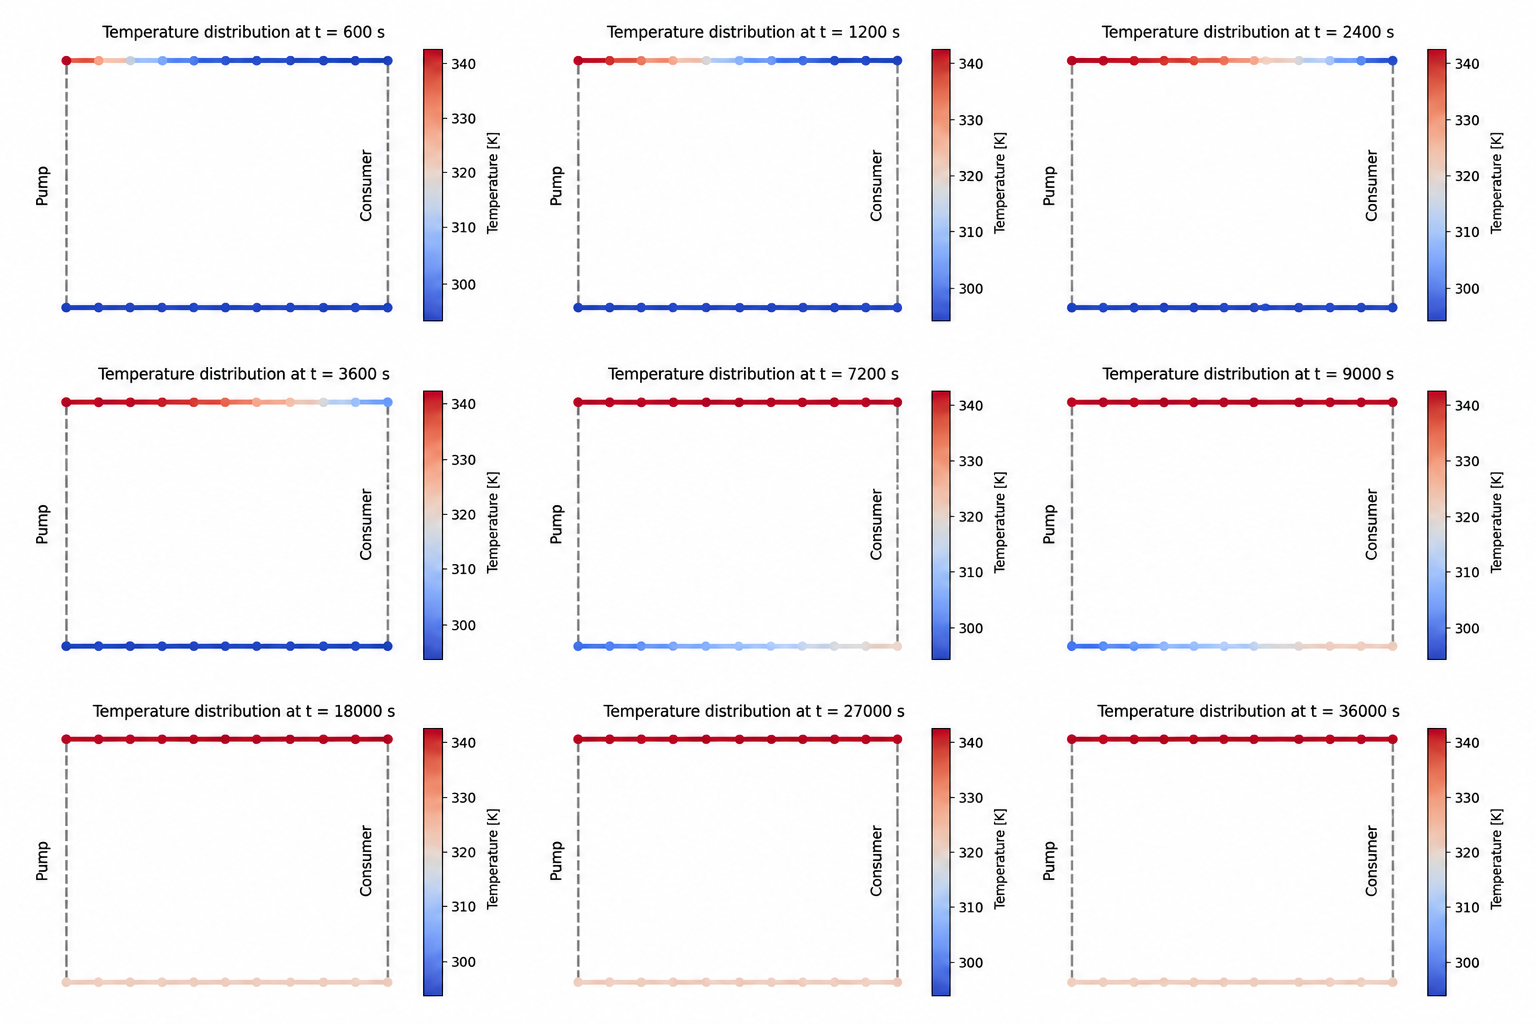

# Junction Temperatures During the Simulation

The following table shows the junction temperatures during the transient simulation.


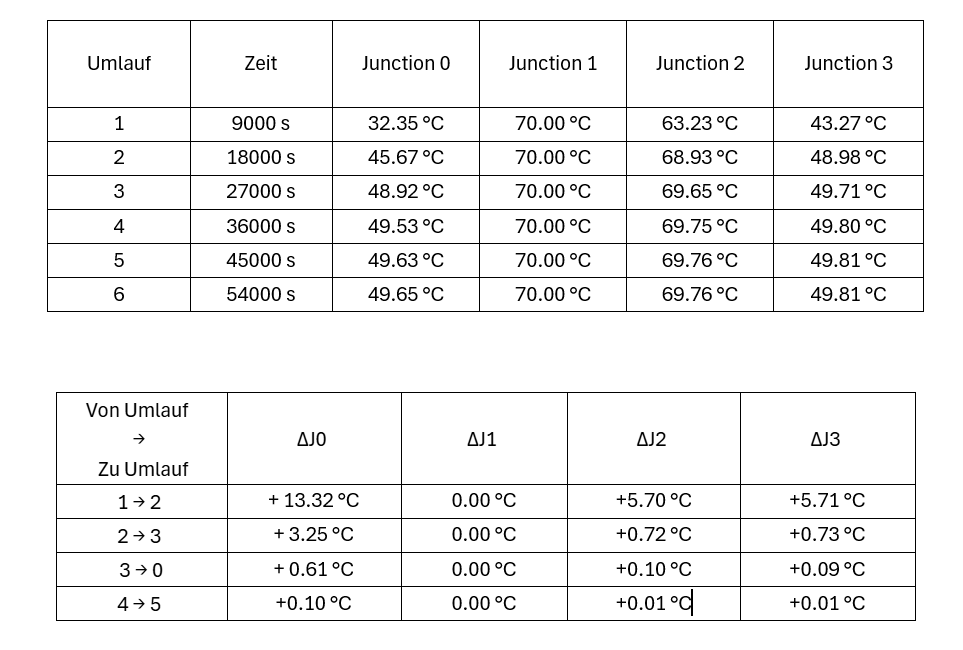
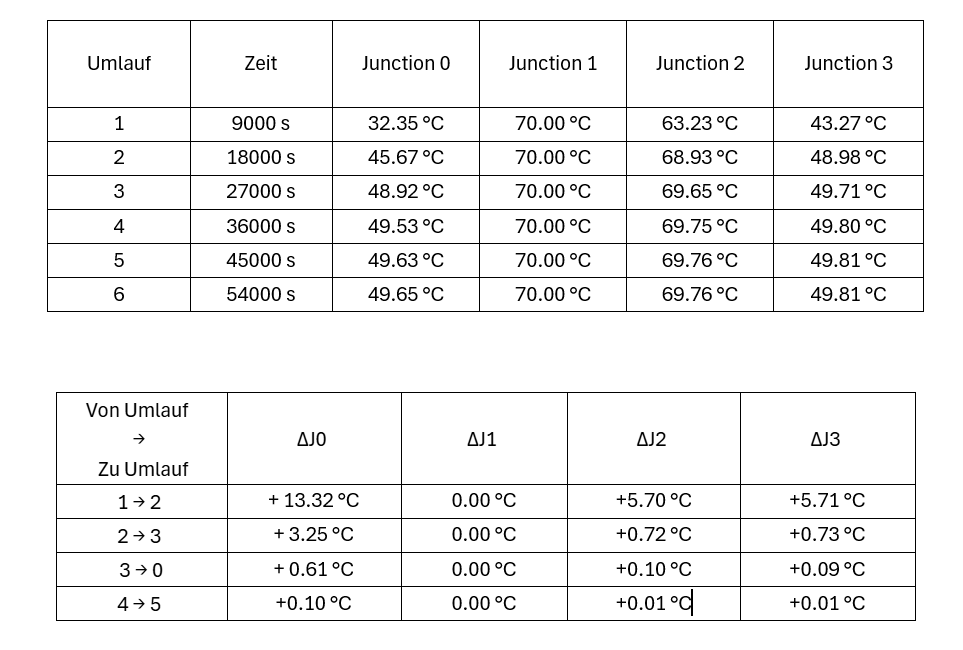
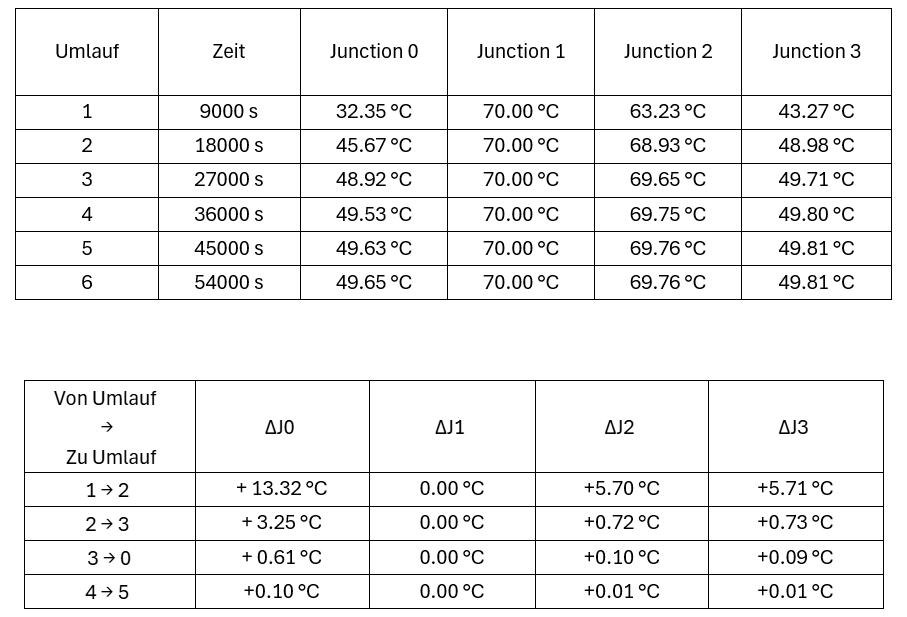
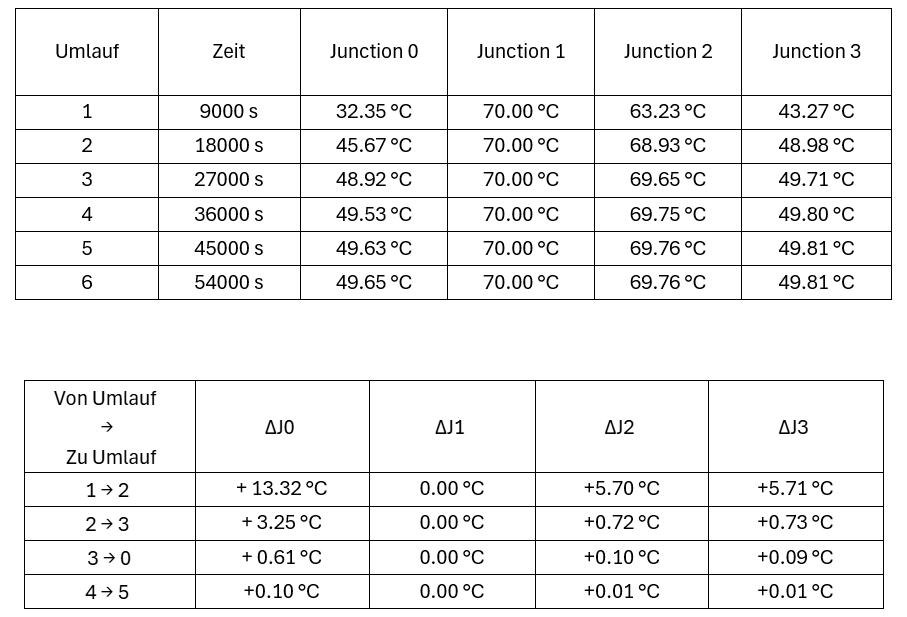

In [18]:
ow._np_to_pd()

temp = ow.output["res_junction.t_k"]
umlauf_s = 9000
n_umlaeufe = 3
rows = []

for u in range(1, n_umlaeufe + 1):
    zeit = u * umlauf_s
    row = {
        "Umlauf": u,
        "Zeit": zeit,
        "junction 0": temp.loc[zeit, 0] - 273.15,
        "junction 1": temp.loc[zeit, 1] - 273.15,
        "junction 2": temp.loc[zeit, 2] - 273.15,
        "junction 3": temp.loc[zeit, 3] - 273.15,
    }
    rows.append(row)

t_k_table = pd.DataFrame(rows)
display(t_k_table.round(2))

,Umlauf,Zeit,junction 0,junction 1,junction 2,junction 3
0,1,9000,26.16,70.0,67.95,47.95
1,2,18000,47.06,70.0,68.21,48.21
2,3,27000,47.07,70.0,68.21,48.21


# Discussion

The results show a physically plausible transient temperature behavior in the closed district heating loop. The supply temperature at Junction 1 remains constant at 70 °C because the circulation pump continuously injects hot water into the network.

The remaining junctions heat up gradually over time. In particular, the return line shows a delayed temperature increase because the initially cold water inside the network is progressively replaced by warmer water.

The temperature plots show that after approximately one circulation time (about 9000 s), the supply line is already close to its final temperature. However, the return line has not yet reached thermal equilibrium. During the following circulation, the return temperature continues to increase until the system approaches a stationary state.

The simulation was performed in sequential mode. Therefore, pandapipes solves the hydraulic and thermal equations consecutively at each time step. Although pandapipes does not model a fully coupled thermo-hydraulic transient system, it is well suited for qualitative investigations of temperature propagation and thermal dynamics in district heating networks.

# Conclusion

This example demonstrates how transient thermal simulations can be performed in pandapipes for closed district heating networks.

The simulation shows:

- gradual heating of the return line,
- delayed temperature propagation through the network,
- and convergence towards a stationary thermal state after several circulation cycles.

Using pipe sections together with `transient=True` allows pandapipes to represent the spatial and temporal evolution of temperatures inside the network in a simple and efficient way.